In [ ]:
from Modules.cartographie import Cartographie

ModuleNotFoundError: No module named 'Modules'

In [ ]:
from cartiflette import carti_download
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import LinearSegmentedColormap
import numpy as np


class Cartographie:
    def __init__(self):
        self.departement_borders = None

    def does_departement_borders_exist(self):
        return self.departement_borders is not None

    def download_departement_borders(
        self,
        values: list[str] = ["France"],
        crs: int = 4326,
        borders: str = "DEPARTEMENT",
        vectorfile_format: str = "geojson",
        simplification: int = 50,
        filter_by: str = "FRANCE_ENTIERE_DROM_RAPPROCHES",
        source: str = "EXPRESS-COG-CARTO-TERRITOIRE",
        year: int = 2022
    ):
        if not self.does_departement_borders_exist():
            try:
                self.departement_borders = carti_download(
                    values=values,
                    crs=crs,
                    borders=borders,
                    vectorfile_format=vectorfile_format,
                    simplification=simplification,
                    filter_by=filter_by,
                    source=source,
                    year=year,
                )
            except Exception as e:
                print(
                    "Une erreur s'est produite lors du téléchargement"
                    f" des frontières des départements: {e}"
                )
        else:
            print("Les frontières des départements ont déjà été téléchargées.")

    def filtrer_score_candidat(
        self,
        df_score: pd.DataFrame, canditat: str = "Marine Le Pen", departement_code: str = None,
        afficher_carte: bool = False,
        figSize: tuple[int, int] = (10, 10)
    ) -> pd.DataFrame:
        if not ['code_departement', 'candidat', 'votes', 'score'] in df_score.columns:
            raise ValueError(
                "Le DataFrame df_score doit contenir les colonnes 'code_departement'"
                ", 'candidat', 'votes' et 'score'."
            )
        if not isinstance(canditat, str):
            raise ValueError(
                "Le paramètre 'canditat' doit être une chaîne de caractères."
            )
        if not isinstance(departement_code, str) and departement_code is not None:
            raise ValueError(
                "Le paramètre 'departement_code' doit être un str.")
        if not isinstance(afficher_carte, bool):
            raise ValueError(
                "Le paramètre 'afficher_carte' doit être un booléen (True ou False)."
            )
        # Filtrer le DataFrame pour ne conserver que les lignes correspondant au candidat spécifié
        df_candidat = df_score[df_score['candidat'].apply(lambda x: x == str(canditat)).lower() == str(canditat).lower()]

        # Si un DataFrame de code département est fourni, fusionner les deux DataFrames
        if departement_code is not None:
            if 'fr_etranger' == departement_code.lower():
                raise ValueError(
                    "Veuillez fournir un code de département valide pour la france, 'fr_etranger' n'est pas un code de département valide."
                )
            df_candidat = df_candidat[df_candidat['code_departement']==departement_code]

        df_plot = self.departement_borders.copy()
        df_plot = df_plot.merge(df_candidat, left_on='code_departement', right_on='code_departement', how='left')
        self.fig, self.ax = plt.subplots(1, 1, figsize=figSize)

        # Plot avec légende personnalisée
        vmin, vmax = df_plot['score'].min(), df_plot['score'].max()  # limites du gradient
        colors = ["#68BBFF", "#ffff", "#C5233E"]  # bleu clair -> blanc-> rose
        cmap = LinearSegmentedColormap.from_list("blue_pink", colors)

        df_plot.plot(column='score', cmap=cmap, linewidth=0.8, edgecolor='black',
                    legend=True, ax=self.ax,
                    legend_kwds={
                        'label': "% par rapport à la moyenne nationale",        # titre de la légende
                        'orientation': "horizontal",   # orientation de la barre
                        'shrink': 0.5               # réduire la taille de la barre
                    })

        # Flèche du Nord
        self.ax.annotate('N', xy=(0.95, 0.95), xytext=(0.95, 0.90),
                    arrowprops=dict(facecolor='black', width=5, headwidth=15),
                    ha='center', va='center', fontsize=14, xycoords=self.ax.transAxes)

        # Échelle en km
        scalebar = ScaleBar(1, units="m", dimension="si-length", location='lower right', pad=0.5, color='black', frameon=False)
        self.ax.add_artist(scalebar)

        # Supprimer axes
        self.ax.set_axis_off()

        # Titre
        self.ax.set_title("Surreprésentation fictive de Marine LE PEN par département", fontsize=16)

        if afficher_carte:
            plt.show()


In [16]:
cartographie = Cartographie()
cartographie.download_departement_borders()

In [17]:
import geopandas as gpd
cartographie.departement_borders.head()

,INSEE_DEP,PAYS,LIBELLE_DEPARTEMENT,POPULATION,SOURCE,geometry
0,43,France,Haute-Loire,227570,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((3.89745 45.35699, 3.89691 45.35631, ..."
1,65,France,Hautes-Pyrénées,229567,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-0.09705 43.5822, -0.09642 43...."
2,29,France,Finistère,915090,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-3.97907 47.70396, -3.98004 47..."
3,22,France,Côtes-d'Armor,600582,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"MULTIPOLYGON (((-3.20174 48.85198, -3.20193 48..."
4,38,France,Isère,1271166,IGN:EXPRESS-COG-CARTO-TERRITOIRE,"POLYGON ((5.10149 45.81356, 5.09828 45.80627, ..."


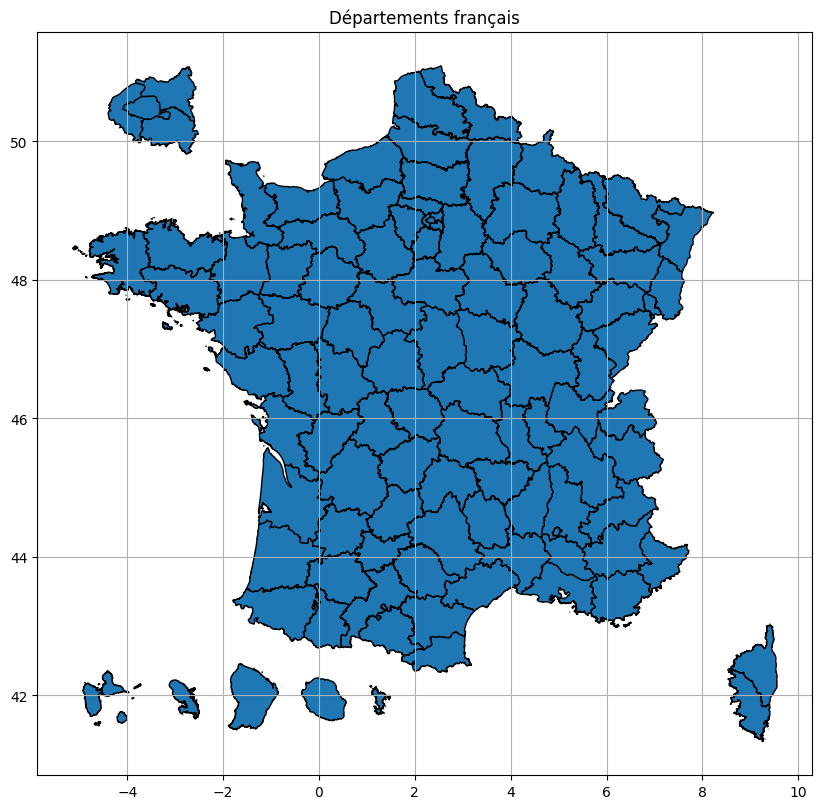

In [20]:
import matplotlib.pyplot as plt

ax = cartographie.departement_borders.plot(figsize=(10,10), edgecolor='black')
ax.grid(True)  # active la grille
ax.set_title("Départements français")
plt.show()

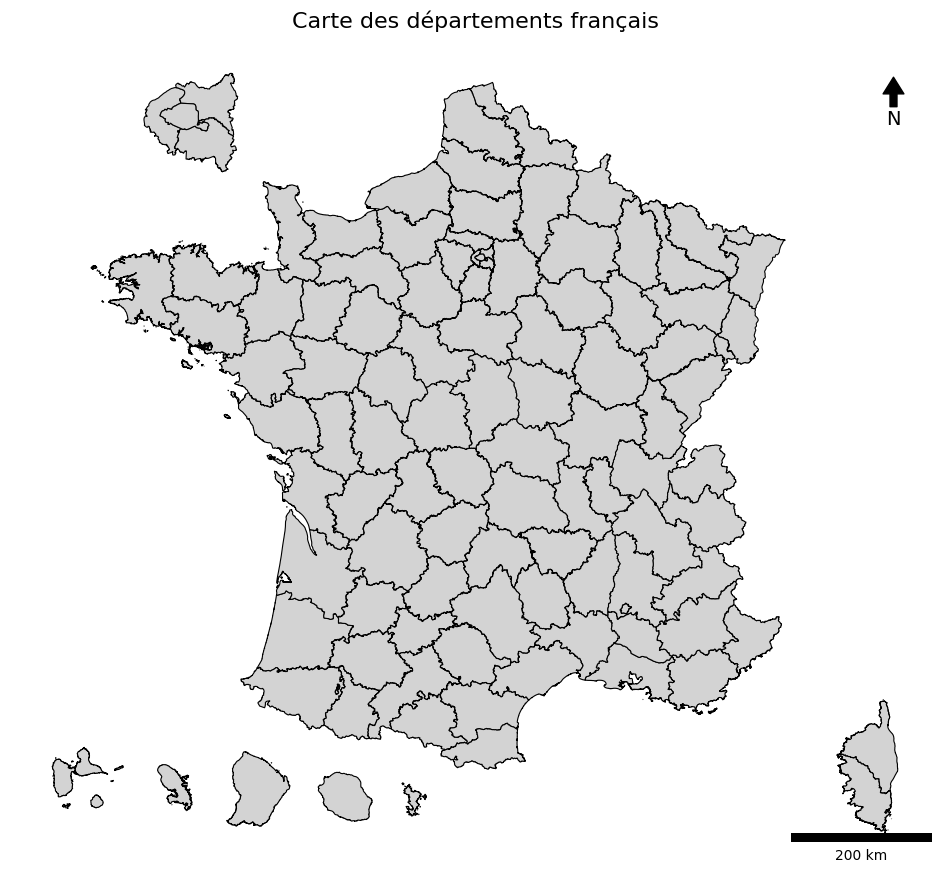

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

# Projection métrique
df_map = cartographie.departement_borders.to_crs(epsg=2154)  # Lambert-93

# Figure
fig, ax = plt.subplots(1, 1, figsize=(12, 14))

# Tracer départements
df_map.plot(linewidth=0.8, edgecolor='black', color='lightgrey', ax=ax)

# Flèche du Nord
ax.annotate('N', xy=(0.95, 0.95), xytext=(0.95, 0.90),
            arrowprops=dict(facecolor='black', width=5, headwidth=15),
            ha='center', va='center', fontsize=14, xycoords=ax.transAxes)

# Échelle en km
scalebar = ScaleBar(1, units="m", dimension="si-length", location='lower right', pad=0.5, color='black', frameon=False)
ax.add_artist(scalebar)

# Supprimer axes pour rendu propre
ax.set_axis_off()

# Titre
ax.set_title("Carte des départements français", fontsize=16)

plt.show()

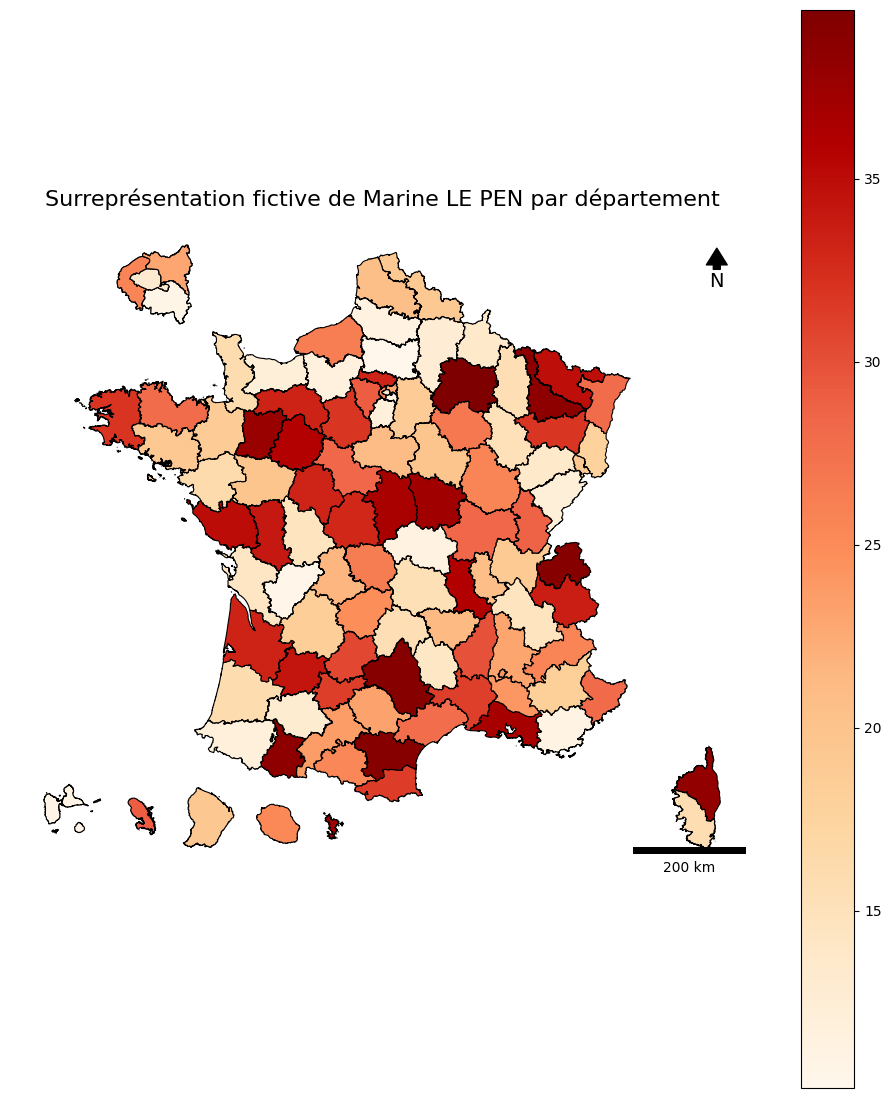

In [27]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

# ---- 1️⃣ Exemple de GeoDataFrame des départements ----
# Ici on utilise une copie réduite pour l'exemple
df_map = cartographie.departement_borders.copy()

# Projection métrique pour échelle
df_map = df_map.to_crs(epsg=2154)  # Lambert-93

# ---- 2️⃣ Créer des scores fictifs pour un candidat ----
import numpy as np
np.random.seed(42)  # pour reproductibilité

df_scores = pd.DataFrame({
    'code_departement': df_map['INSEE_DEP'],
    'candidat': 'Marine LE PEN',
    'score': np.random.uniform(10, 40, size=len(df_map))  # scores aléatoires en %
})

# ---- 3️⃣ Merge GeoDataFrame + scores ----
df_plot = df_map.merge(df_scores, left_on='INSEE_DEP', right_on='code_departement')

# ---- 4️⃣ Tracer la carte ----
fig, ax = plt.subplots(1, 1, figsize=(12, 14))

# Départements colorés par score
df_plot.plot(column='score', cmap='OrRd', linewidth=0.8, edgecolor='black', legend=True, ax=ax)

# Flèche du Nord
ax.annotate('N', xy=(0.95, 0.95), xytext=(0.95, 0.90),
            arrowprops=dict(facecolor='black', width=5, headwidth=15),
            ha='center', va='center', fontsize=14, xycoords=ax.transAxes)

# Échelle en km
scalebar = ScaleBar(1, units="m", dimension="si-length", location='lower right', pad=0.5, color='black', frameon=False)
ax.add_artist(scalebar)

# Supprimer axes
ax.set_axis_off()

# Titre
ax.set_title("Surreprésentation fictive de Marine LE PEN par département", fontsize=16)

plt.show()

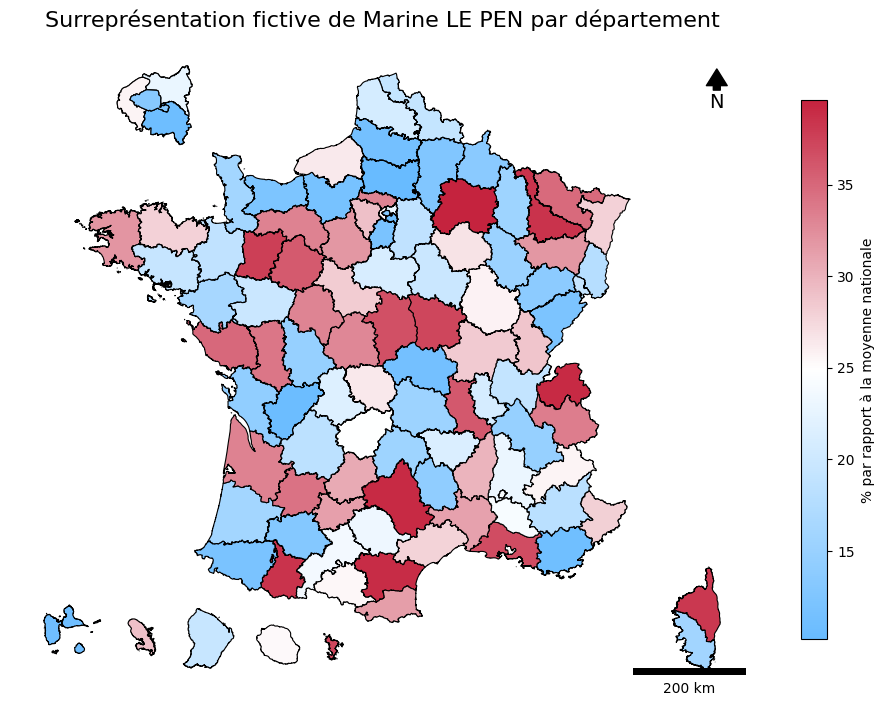

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# 1️⃣ GeoDataFrame exemple (départements fictifs)
df_map = cartographie.departement_borders.copy()
df_map = df_map.to_crs(epsg=2154)  # Lambert-93

# 2️⃣ Scores fictifs
np.random.seed(42)
df_scores = pd.DataFrame({
    'code_departement': df_map['INSEE_DEP'],
    'candidat': 'Marine LE PEN',
    'score': np.random.uniform(10, 40, size=len(df_map))
})

# 3️⃣ Merge
df_plot = df_map.merge(df_scores, left_on='INSEE_DEP', right_on='code_departement')

# 4️⃣ Création figure
fig, ax = plt.subplots(1, 1, figsize=(12, 14))

# 5️⃣ Plot avec légende personnalisée
vmin, vmax = df_plot['score'].min(), df_plot['score'].max()  # limites du gradient
colors = ["#68BBFF", "#ffff", "#C5233E"]  # bleu clair -> rose
cmap = LinearSegmentedColormap.from_list("blue_pink", colors)

df_plot.plot(column='score', cmap=cmap, linewidth=0.8, edgecolor='black',
             legend=True, ax=ax,
             legend_kwds={
                 'label': "% par rapport à la moyenne nationale",        # titre de la légende
                 'orientation': "vertical",   # orientation de la barre
                 'shrink': 0.5               # réduire la taille de la barre
             })

# 6️⃣ Flèche du Nord
ax.annotate('N', xy=(0.95, 0.95), xytext=(0.95, 0.90),
            arrowprops=dict(facecolor='black', width=5, headwidth=15),
            ha='center', va='center', fontsize=14, xycoords=ax.transAxes)

# 7️⃣ Échelle en km
scalebar = ScaleBar(1, units="m", dimension="si-length", location='lower right', pad=0.5, color='black', frameon=False)
ax.add_artist(scalebar)

# 8️⃣ Supprimer axes
ax.set_axis_off()

# 9️⃣ Titre
ax.set_title("Surreprésentation fictive de Marine LE PEN par département", fontsize=16)

plt.show()